---
### 05. 다중분류
---

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import *

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### Functions
- make_DataSet : 다중분류용으로 새로 생성 필요
- train, evaluate, learning_curve : 이전 실습과 동일

In [42]:
# make dataset ~ 다중분류용 새로 생성
def make_DataSet(X_train, X_val, y_train, y_val, batch_size=32):
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)
  X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
  y_val_tensor = torch.tensor(y_val, dtype=torch.long)
  train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, X_val_tensor, y_val_tensor

In [43]:
# train
def train(dataloader, model, loss_fn, optimizer, device):
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  tr_loss = 0

  model.train()
  for X, y in dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    tr_loss += loss

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

  tr_loss /= num_batches
  return tr_loss.item()

# evaluate
def evaluate(X_val_tensor, y_val_tensor, model, loss_fn, device):
  model.eval()
  with torch.no_grad():
    X, y = X_val_tensor.to(device), y_val_tensor.to(device)
    pred = model(X)
    eval_loss = loss_fn(pred, y).item()
  return eval_loss, pred

# vizualize
def learning_curve(tr_loss_list, val_loss_list):
  epochs = list(range(1, len(tr_loss_list)+1))
  plt.plot(epochs, tr_loss_list, label='tr_err', marker='.')
  plt.plot(epochs, val_loss_list, label='val_err', marker='.')
  plt.xlabel('epochs')
  plt.ylabel('loss')
  plt.legend()
  plt.grid()
  plt.show()

In [44]:
# data loading
df = pd.read_csv('data/iris.csv')
print(df.shape)
display(df.head())

# target
y = df['Species']
X = df.drop('Species', axis=1)

# target encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print('y is =', np.unique(y))

# validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# data loader
train_loader, X_val_ts, y_val_ts = make_DataSet(X_train, X_val, y_train, y_val, 32)

(150, 5)


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


y is = [0 1 2]


In [45]:
# model
n_feature = X.shape[1]     # 4
n_class = len(le.classes_) # 3

model = nn.Sequential(
    nn.Linear(n_feature, n_class)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.1)

In [46]:
# train
epochs = 50
tr_loss_list, val_loss_list = [],[]

for i in range(epochs):
  tr_loss = train(train_loader, model, loss_fn, optimizer, device)
  val_loss, _ = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)
  tr_loss_list.append(tr_loss)
  val_loss_list.append(val_loss)
  print(f"Epoch {i+1}, train loss: {tr_loss:.4f}, val loss: {val_loss:.4f}")

Epoch 1, train loss: 1.0700, val loss: 0.9050
Epoch 2, train loss: 0.8639, val loss: 0.7425
Epoch 3, train loss: 0.7107, val loss: 0.6462
Epoch 4, train loss: 0.6097, val loss: 0.5420
Epoch 5, train loss: 0.5518, val loss: 0.4903
Epoch 6, train loss: 0.5113, val loss: 0.4618
Epoch 7, train loss: 0.4715, val loss: 0.4285
Epoch 8, train loss: 0.4448, val loss: 0.4058
Epoch 9, train loss: 0.4223, val loss: 0.3870
Epoch 10, train loss: 0.4053, val loss: 0.3705
Epoch 11, train loss: 0.3921, val loss: 0.3596
Epoch 12, train loss: 0.3831, val loss: 0.3474
Epoch 13, train loss: 0.3652, val loss: 0.3298
Epoch 14, train loss: 0.3514, val loss: 0.3187
Epoch 15, train loss: 0.3453, val loss: 0.3096
Epoch 16, train loss: 0.3443, val loss: 0.2993
Epoch 17, train loss: 0.3318, val loss: 0.2910
Epoch 18, train loss: 0.3168, val loss: 0.2877
Epoch 19, train loss: 0.3170, val loss: 0.2760
Epoch 20, train loss: 0.3089, val loss: 0.2682
Epoch 21, train loss: 0.3030, val loss: 0.2614
Epoch 22, train loss: 

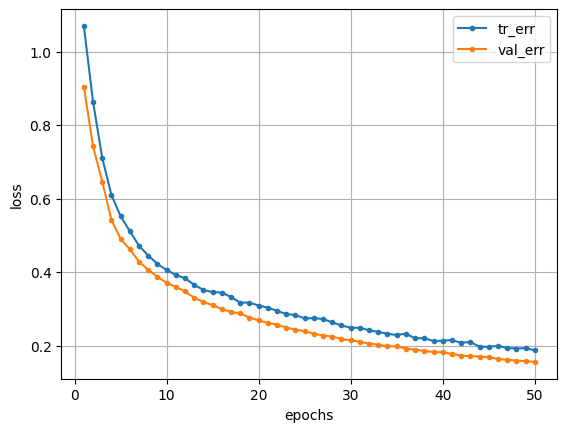

In [47]:
learning_curve(tr_loss_list, val_loss_list)

In [48]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

pred1 = pred.numpy()
print('1) 3개 클래스에 대한 logit :', '\n', pred1[:5])
print('-'*50)

# logit값을 softmax를 통과시켜 확률로 변환
pred2 = nn.functional.softmax(pred, dim=1)
pred2 = pred2.numpy()
print("2) 3개 클래스에 대한 확률값 :", '\n', np.round(pred2[:5], 2))
print('-'*50)

# argmax로 확률값이 가장 높은 클래스 표시
pred3 = np.argmax(pred.numpy(), axis=1)
print('3) 클래스 예측 :', pred3[:5])

1) 3개 클래스에 대한 logit : 
 [[-2.3948083   2.3872657   0.79574823]
 [ 5.394849    1.9878492  -5.9599404 ]
 [-9.584442    2.4142587   6.710398  ]
 [-2.4820108   1.9450091   1.1427989 ]
 [-3.8779154   2.519893    1.8081517 ]]
--------------------------------------------------
2) 3개 클래스에 대한 확률값 : 
 [[0.01 0.83 0.17]
 [0.97 0.03 0.  ]
 [0.   0.01 0.99]
 [0.01 0.68 0.31]
 [0.   0.67 0.33]]
--------------------------------------------------
3) 클래스 예측 : [1 0 2 1 1]


In [49]:
# Report : 정수값과 비교해야 하므로, argmax 변환을 거친 pred3 사용
report = classification_report(y_val_ts.numpy(), pred3, target_names=le.classes_)
print(report)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [51]:
_, pred = evaluate(X_val_ts, y_val_ts, model, loss_fn, device)

pred3 = np.argmax(pred.numpy(), axis=1)
print('3) 클래스 예측 :', pred3[:5])

3) 클래스 예측 : [1 0 2 1 1]
